# A Satisficing Voter Model

Python port of the browser simulation (`sim.js`). Voters and candidates are placed uniformly in $[-1,1]^d$. True utility is $u_i(c) = -\|v_i - p_c\|_\nu^2$.

**Two imperfection parameters:**
- **Epistemic noise $t \in [0,1]$:** perceived utility $\tilde{u}_i = t \cdot u_i + (1-t) \cdot \eta_i$, where $\eta_i \sim \mathcal{N}(\bar{u}, \sigma_u^2)$.
- **Participation friction $\ell \in [0,1]$:** each voter only votes on their top $K = \max(1, \lceil \ell \cdot m \rceil)$ candidates.

**VSE** (Voter Satisfaction Efficiency):
$$\text{VSE}_M(t,\ell) = \frac{\mathbb{E}[\text{SW}(w_M)] - \mathbb{E}[\text{SW}(\text{random})]}{\mathbb{E}[\text{SW}(c^*)] - \mathbb{E}[\text{SW}(\text{random})]}$$

0% = as good as random; 100% = always picks the optimal candidate.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from scipy.stats import norm as scipy_norm, binom as scipy_binom
import warnings
warnings.filterwarnings('ignore')

try:
    import pandas as pd
    HAS_PANDAS = True
except ImportError:
    HAS_PANDAS = False
    print('pandas not found — table output will use plain text')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

pandas not found — table output will use plain text


## Model Settings
Edit this cell to configure the simulation before running.

In [ ]:
# ── Simulation parameters ─────────────────────────────────────────────────────
NV   = 85     # voters
NC   = 8      # candidates
NTR  = 200    # trials per grid point
NG   = 8      # grid resolution (NG x NG over t and l)
ND   = 2      # spatial dimensions
NORM = 'l1'   # distance norm: 'l1' (Manhattan), 'l2' (Euclidean), 'linf' (Chebyshev)
SEED = 42     # random seed (None = random)

# ── Runoff options ────────────────────────────────────────────────────────────
# Use true underlying utilities for the Top 2 runoff comparison (see README).
USE_TRUE_RUNOFF = True

# ── Methods to include ────────────────────────────────────────────────────────
METHODS_ENABLED = {
    'Plurality':        True,
    'Plurality Top 2':  True,
    'Approval':         True,
    'Approval Top 2':   True,
    'RCV':              True,
    'STAR':             True,
    'Condorcet':        True,
    'Score':            False,
    'Borda':            False,
}

# ── Hypothesis test alpha level ───────────────────────────────────────────────
ALPHA = 0.01

# ── Display order and colors (matches browser tool) ──────────────────────────
METHOD_ORDER = [
    'Plurality', 'Plurality Top 2', 'Approval', 'Approval Top 2',
    'RCV', 'STAR', 'Condorcet', 'Score', 'Borda',
]
METHOD_COLORS = {
    'Plurality':        '#e05555',
    'Plurality Top 2':  '#cc6a5a',
    'Approval':         '#4ec96a',
    'Approval Top 2':   '#2fa07c',
    'RCV':              '#e09944',
    'STAR':             '#4ab8e0',
    'Condorcet':        '#9b6be0',
    'Score':            '#b8e04a',
    'Borda':            '#d4c94a',
}

## Core Functions

In [3]:
RNG = np.random.default_rng(SEED)


def make_election(nv, nc, nd=2, norm='l1'):
    """True utilities: u[i, c] = -||v_i - p_c||_norm^2"""
    v = RNG.uniform(-1, 1, (nv, nd))
    c = RNG.uniform(-1, 1, (nc, nd))
    diff = v[:, np.newaxis, :] - c[np.newaxis, :, :]  # (nv, nc, nd)
    key = str(norm).lower()
    if key == 'l1':
        dist = np.sum(np.abs(diff), axis=2)
    elif key == 'linf':
        dist = np.max(np.abs(diff), axis=2)
    else:
        dist = np.sqrt(np.sum(diff ** 2, axis=2))
    return -(dist ** 2)


def add_noise(u, t):
    """Perceived utilities: pu = t*u + (1-t)*eta, eta ~ N(mean(u), std(u))"""
    if t >= 1.0:
        return u.copy()
    mu = u.mean()
    sg = u.std()
    if sg < 1e-9:
        sg = 1.0
    eta = RNG.normal(mu, sg, u.shape)
    return t * u + (1 - t) * eta


def K_of(l, nc):
    """Number of candidates each voter considers."""
    return max(1, int(np.ceil(l * nc)))


def top_idx(pu, l):
    """Top-K candidate indices per voter (nv x K), sorted descending by perceived utility."""
    K = K_of(l, pu.shape[1])
    return np.argsort(-pu, axis=1)[:, :K]


def vse(sw_w, sw_rand, sw_opt):
    """Voter Satisfaction Efficiency."""
    d = sw_opt - sw_rand
    return (sw_w - sw_rand) / d if d > 1e-9 else 1.0

## Voting Methods

In [4]:
def plurality_winner(pu, **kw):
    top1 = np.argmax(pu, axis=1)
    return int(np.argmax(np.bincount(top1, minlength=pu.shape[1])))


def runoff_plurality_winner(pu, u=None, use_true_runoff=True, **kw):
    top1 = np.argmax(pu, axis=1)
    counts = np.bincount(top1, minlength=pu.shape[1])
    order = np.argsort(-counts)
    f1, f2 = int(order[0]), int(order[1])
    mat = u if (use_true_runoff and u is not None) else pu
    return f1 if np.sum(mat[:, f1] > mat[:, f2]) >= np.sum(mat[:, f2] > mat[:, f1]) else f2


def _approval_ballots(pu, l):
    """(nv, nc) boolean approval matrix."""
    nv, nc = pu.shape
    tidx = top_idx(pu, l)
    considered = np.zeros((nv, nc), dtype=bool)
    for i in range(nv):
        considered[i, tidx[i]] = True
    global_mean = pu.mean(axis=1, keepdims=True)
    approvals = considered & (pu > global_mean)
    # fallback: always approve top candidate if nothing approved
    no_vote = ~approvals.any(axis=1)
    for i in np.where(no_vote)[0]:
        approvals[i, tidx[i, 0]] = True
    return approvals


def approval_winner(pu, l, **kw):
    return int(np.argmax(_approval_ballots(pu, l).sum(axis=0)))


def runoff_approval_winner(pu, l, u=None, use_true_runoff=True, **kw):
    totals = _approval_ballots(pu, l).sum(axis=0)
    order = np.argsort(-totals)
    f1, f2 = int(order[0]), int(order[1])
    mat = u if (use_true_runoff and u is not None) else pu
    return f1 if np.sum(mat[:, f1] > mat[:, f2]) >= np.sum(mat[:, f2] > mat[:, f1]) else f2


def _score_ballots(pu, l):
    """(nv, nc) score ballots on 0-5 scale."""
    nv, nc = pu.shape
    tidx = top_idx(pu, l)
    ballots = np.zeros((nv, nc))
    for i in range(nv):
        row = pu[i]
        lo, hi = row.min(), row.max()
        denom = (hi - lo) if (hi - lo) > 1e-9 else 1.0
        flat = (hi - lo) < 1e-9
        for c in tidx[i]:
            ballots[i, c] = 5.0 if flat else 5.0 * (row[c] - lo) / denom
    return ballots


def score_winner(pu, l, **kw):
    return int(np.argmax(_score_ballots(pu, l).sum(axis=0)))


def star_winner(pu, l, **kw):
    ballots = _score_ballots(pu, l)
    totals = ballots.sum(axis=0)
    order = np.argsort(-totals)
    f1, f2 = int(order[0]), int(order[1])
    return f1 if np.sum(ballots[:, f1] > ballots[:, f2]) >= np.sum(ballots[:, f2] > ballots[:, f1]) else f2


def irv_winner(pu, l, **kw):
    ballots = top_idx(pu, l)  # (nv, K)
    nv, K = ballots.shape
    nc = pu.shape[1]
    remaining = list(range(nc))
    remaining_set = set(remaining)
    for _ in range(nc - 1):
        if len(remaining) == 1:
            break
        fp = {c: 0 for c in remaining}
        for i in range(nv):
            for k in range(K):
                c = int(ballots[i, k])
                if c in remaining_set:
                    fp[c] += 1
                    break
        total = sum(fp.values())
        for c, votes in fp.items():
            if votes > total / 2:
                return c
        elim = min(remaining, key=lambda c: fp.get(c, 0))
        remaining.remove(elim)
        remaining_set.discard(elim)
    return remaining[0]


def borda_winner(pu, l, **kw):
    nv, nc = pu.shape
    tidx = top_idx(pu, l)
    K = tidx.shape[1]
    pts = np.arange(K, 0, -1, dtype=float)
    scores = np.zeros(nc)
    for i in range(nv):
        scores[tidx[i]] += pts
    return int(np.argmax(scores))


def condorcet_winner(pu, l, **kw):
    """Minimax Condorcet: minimize worst pairwise defeat."""
    nv, nc = pu.shape
    tidx = top_idx(pu, l)
    K = tidx.shape[1]
    rm = np.full((nv, nc), K)  # rank matrix; unranked = K (worst)
    for i in range(nv):
        for k, c in enumerate(tidx[i]):
            rm[i, c] = k
    pairwise = np.zeros((nc, nc))
    for a in range(nc):
        for b in range(a + 1, nc):
            wa = int(np.sum(rm[:, a] < rm[:, b]))
            wb = int(np.sum(rm[:, b] < rm[:, a]))
            pairwise[a, b] = wa
            pairwise[b, a] = wb
    # worst defeat for each candidate
    worst = np.zeros(nc)
    for a in range(nc):
        defeats = pairwise[:, a] - pairwise[a, :]
        defeats[a] = 0
        worst[a] = max(0.0, float(defeats.max()))
    return int(np.argmin(worst))


METHOD_FNS = {
    'Plurality':        plurality_winner,
    'Plurality Top 2':  runoff_plurality_winner,
    'Approval':         approval_winner,
    'Approval Top 2':   runoff_approval_winner,
    'RCV':              irv_winner,
    'STAR':             star_winner,
    'Condorcet':        condorcet_winner,
    'Score':            score_winner,
    'Borda':            borda_winner,
}

print('Voting methods loaded:', list(METHOD_FNS.keys()))

Voting methods loaded: ['Plurality', 'Plurality Top 2', 'Approval', 'Approval Top 2', 'RCV', 'STAR', 'Condorcet', 'Score', 'Borda']


## Run Simulation
Runs the full NG×NG grid. With default settings (NG=8, NTR=200) this takes ~1–3 minutes.

In [5]:
def run_grid(
    nv=NV, nc=NC, ntr=NTR, ng=NG, nd=ND, norm=NORM,
    use_true_runoff=USE_TRUE_RUNOFF,
    methods_enabled=METHODS_ENABLED,
    seed=SEED,
):
    global RNG
    RNG = np.random.default_rng(seed)

    t_vals = np.linspace(0, 1, ng)
    l_vals = np.linspace(1 / nc, 1, ng)
    method_names = [m for m in METHOD_ORDER if methods_enabled.get(m, False)]

    # res[m][li, ti] = mean VSE at (l_vals[li], t_vals[ti])
    res = {m: np.zeros((ng, ng)) for m in method_names}
    # trial_vse[m][li, ti, tr] = per-trial VSE (for hypothesis tests)
    trial_vse = {m: np.zeros((ng, ng, ntr)) for m in method_names}

    total_cells = ng * ng
    done = 0
    print(f'Grid {ng}x{ng}, {ntr} trials, {len(method_names)} methods, {nv} voters, {nc} candidates')

    for li, l in enumerate(l_vals):
        for ti, t in enumerate(t_vals):
            for tr in range(ntr):
                u = make_election(nv, nc, nd, norm)
                pu = add_noise(u, t)
                cm = u.mean(axis=0)
                sw_rand = float(cm.mean())
                sw_opt = float(cm.max())
                for m in method_names:
                    w = METHOD_FNS[m](pu, l=l, u=u, use_true_runoff=use_true_runoff)
                    trial_vse[m][li, ti, tr] = vse(float(cm[w]), sw_rand, sw_opt)

            for m in method_names:
                res[m][li, ti] = trial_vse[m][li, ti, :].mean()

            done += 1
            if done % max(1, total_cells // 8) == 0 or done == total_cells:
                print(f'  {done}/{total_cells} cells', end='\r')

    print(f'\nDone. {ng*ng*ntr:,} total trials.')
    return {
        'res': res,
        'trial_vse': trial_vse,
        't_vals': t_vals,
        'l_vals': l_vals,
        'method_names': method_names,
        'params': dict(nv=nv, nc=nc, ntr=ntr, ng=ng, nd=nd, norm=norm),
    }


results = run_grid()

Grid 8x8, 200 trials, 7 methods, 85 voters, 8 candidates
  64/64 cells
Done. 12,800 total trials.


## Axis Slices
Left: VSE vs epistemic noise $t$ with full ballot ($\ell=1$).  
Right: VSE vs participation friction $\ell$ with perfect knowledge ($t=1$).

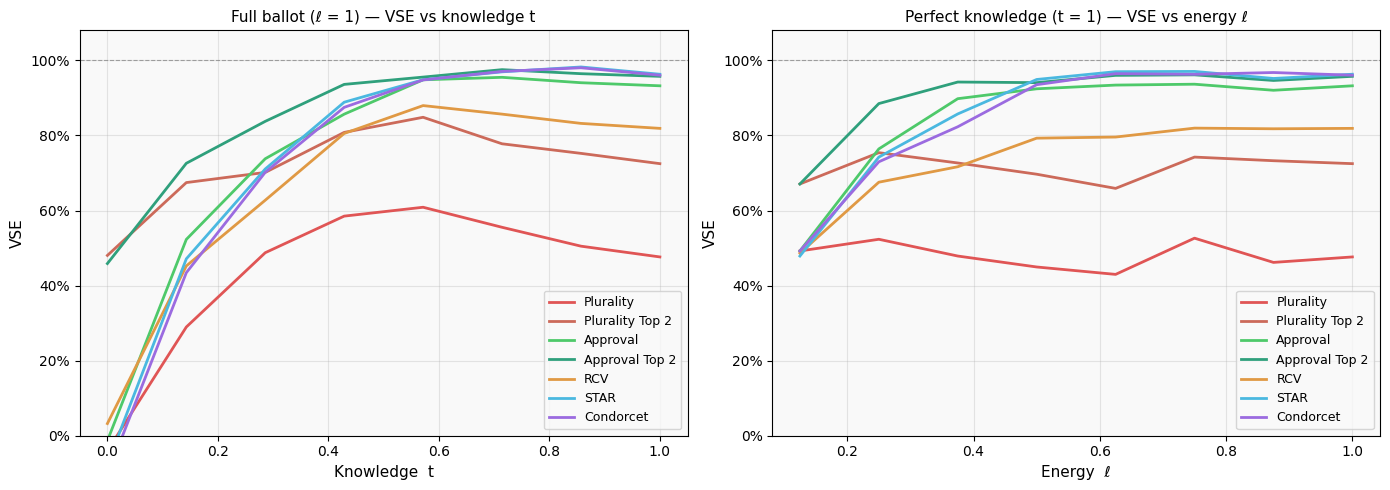

In [6]:
res          = results['res']
t_vals       = results['t_vals']
l_vals       = results['l_vals']
method_names = results['method_names']
ng           = len(t_vals)
li_max       = ng - 1   # l = 1
ti_max       = ng - 1   # t = 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── VSE vs t (l = 1) ─────────────────────────────────────────────────────────
ax = axes[0]
for m in method_names:
    ax.plot(t_vals, res[m][li_max, :],
            label=m, color=METHOD_COLORS.get(m, '#888'), linewidth=2)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.set_xlabel('Knowledge  t', fontsize=11)
ax.set_ylabel('VSE', fontsize=11)
ax.set_title('Full ballot (\u2113 = 1) \u2014 VSE vs knowledge t', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_ylim(0, 1.08)
ax.legend(fontsize=9, loc='lower right')

# ── VSE vs l (t = 1) ─────────────────────────────────────────────────────────
ax = axes[1]
for m in method_names:
    ax.plot(l_vals, res[m][:, ti_max],
            label=m, color=METHOD_COLORS.get(m, '#888'), linewidth=2)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.set_xlabel('Energy  \u2113', fontsize=11)
ax.set_ylabel('VSE', fontsize=11)
ax.set_title('Perfect knowledge (t = 1) \u2014 VSE vs energy \u2113', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_ylim(0, 1.08)
ax.legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

## Scenarios — Bar Charts
VSE at four specific $(t, \ell)$ points. Adjust `SCENARIOS` to change them.

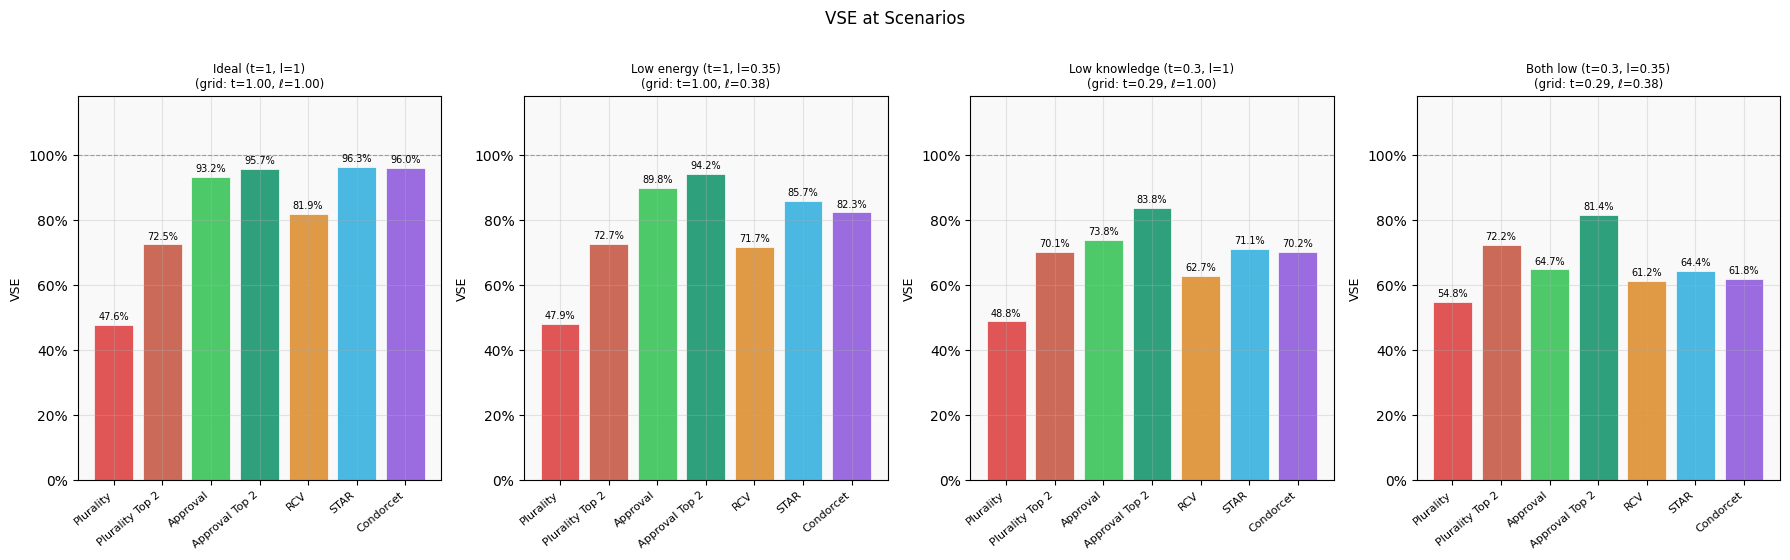

In [ ]:
def closest_idx(arr, v):
    return int(np.argmin(np.abs(arr - v)))

# ── Scenarios for bar charts and hypothesis tests ────────────────────────────
# Each (t, l) is snapped to the nearest grid point.
SCENARIOS = [
    {'label': 'Ideal (t=1, l=1)',            't': 1.0,  'l': 1.00},
    {'label': 'Low energy (t=1, l=0.35)',    't': 1.0,  'l': 0.35},
    {'label': 'Low knowledge (t=0.3, l=1)',  't': 0.3,  'l': 1.00},
    {'label': 'Both low (t=0.3, l=0.35)',    't': 0.3,  'l': 0.35},
]

# Resolve each scenario to the nearest grid indices
scenario_specs = []
for sc in SCENARIOS:
    ti = closest_idx(t_vals, sc['t'])
    li = closest_idx(l_vals, sc['l'])
    actual_t = t_vals[ti]
    actual_l = l_vals[li]
    scenario_specs.append({
        **sc,
        'ti': ti, 'li': li,
        'actual_t': actual_t, 'actual_l': actual_l,
        'display_label': f"{sc['label']}\n(grid: t={actual_t:.2f}, \u2113={actual_l:.2f})",
    })

n_sc = len(scenario_specs)
fig, axes = plt.subplots(1, n_sc, figsize=(4.5 * n_sc, 5.5), sharey=False)
if n_sc == 1:
    axes = [axes]

for ax, sc in zip(axes, scenario_specs):
    vals = [res[m][sc['li'], sc['ti']] for m in method_names]
    colors = [METHOD_COLORS.get(m, '#888') for m in method_names]
    bars = ax.bar(range(len(method_names)), vals, color=colors,
                  edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(len(method_names)))
    ax.set_xticklabels(method_names, rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('VSE', fontsize=9)
    ax.set_title(sc['display_label'], fontsize=8.5)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.set_ylim(0, 1.18)
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{v:.1%}', ha='center', va='bottom', fontsize=7)

plt.suptitle('VSE at Scenarios', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Hypothesis Tests — Helper Functions
- **One-sided mean-diff test:** H1: mean(X − Y) > 0, normal approximation.
- **Sign test:** exact binomial, H1: more positive than negative differences.
- **Bonferroni correction** applied across all pair-cell combinations.

In [8]:
def one_sided_mean_test(deltas):
    """H1: mean(deltas) > 0. Normal approximation. Returns dict."""
    deltas = np.asarray(deltas, dtype=float)
    n = len(deltas)
    if n < 2:
        return dict(mean=np.nan, sd=np.nan, se=np.nan, z=np.nan, p=np.nan,
                    lower_ci=np.nan, upper_ci=np.nan)
    mean = float(np.mean(deltas))
    sd   = float(np.std(deltas, ddof=1))
    se   = sd / np.sqrt(n)
    if sd < 1e-12:
        z = np.inf if mean > 0 else -np.inf
        p = 0.0 if mean > 0 else 1.0
        return dict(mean=mean, sd=sd, se=se, z=z, p=p,
                    lower_ci=mean, upper_ci=mean)
    z = mean / se
    p = float(np.clip(1 - scipy_norm.cdf(z), 0, 1))
    z99 = float(scipy_norm.ppf(0.995))   # two-sided 99% CI
    z95 = float(scipy_norm.ppf(0.95))    # one-sided 95% lower bound
    return dict(
        mean=mean, sd=sd, se=se, z=z, p=p,
        lower_ci_95=mean - z95 * se,    # one-sided 95% lower bound
        lower_ci=mean - z99 * se,       # two-sided 99% CI lower
        upper_ci=mean + z99 * se,       # two-sided 99% CI upper
    )


def one_sided_sign_test(deltas):
    """Exact sign test: H1: median(deltas) > 0."""
    deltas = np.asarray(deltas, dtype=float)
    pos   = int(np.sum(deltas >  1e-12))
    neg   = int(np.sum(deltas < -1e-12))
    ties  = int(len(deltas) - pos - neg)
    n_eff = pos + neg
    if n_eff == 0:
        return dict(pos=0, neg=0, ties=ties, n_eff=0, p=1.0)
    p = float(np.clip(scipy_binom.sf(pos - 1, n_eff, 0.5), 0, 1))
    return dict(pos=pos, neg=neg, ties=ties, n_eff=n_eff, p=p)


def bonferroni_adjust(p_vals):
    m = len(p_vals)
    return [min(1.0, p * m) for p in p_vals]


print('Hypothesis test functions ready.')

Hypothesis test functions ready.


## Scenario Pairwise Hypothesis Tests

For each scenario, a matrix answers: **does the 99% CI for (row VSE − col VSE) exclude zero?**

- **Green / Yes:** CI is entirely above 0 — sufficient evidence the row method outperforms the column method at this scenario.
- **Red / No:** CI contains 0 — not sufficient evidence.

CIs are computed from the per-trial VSE differences (paired, so variance of the mean is reduced).

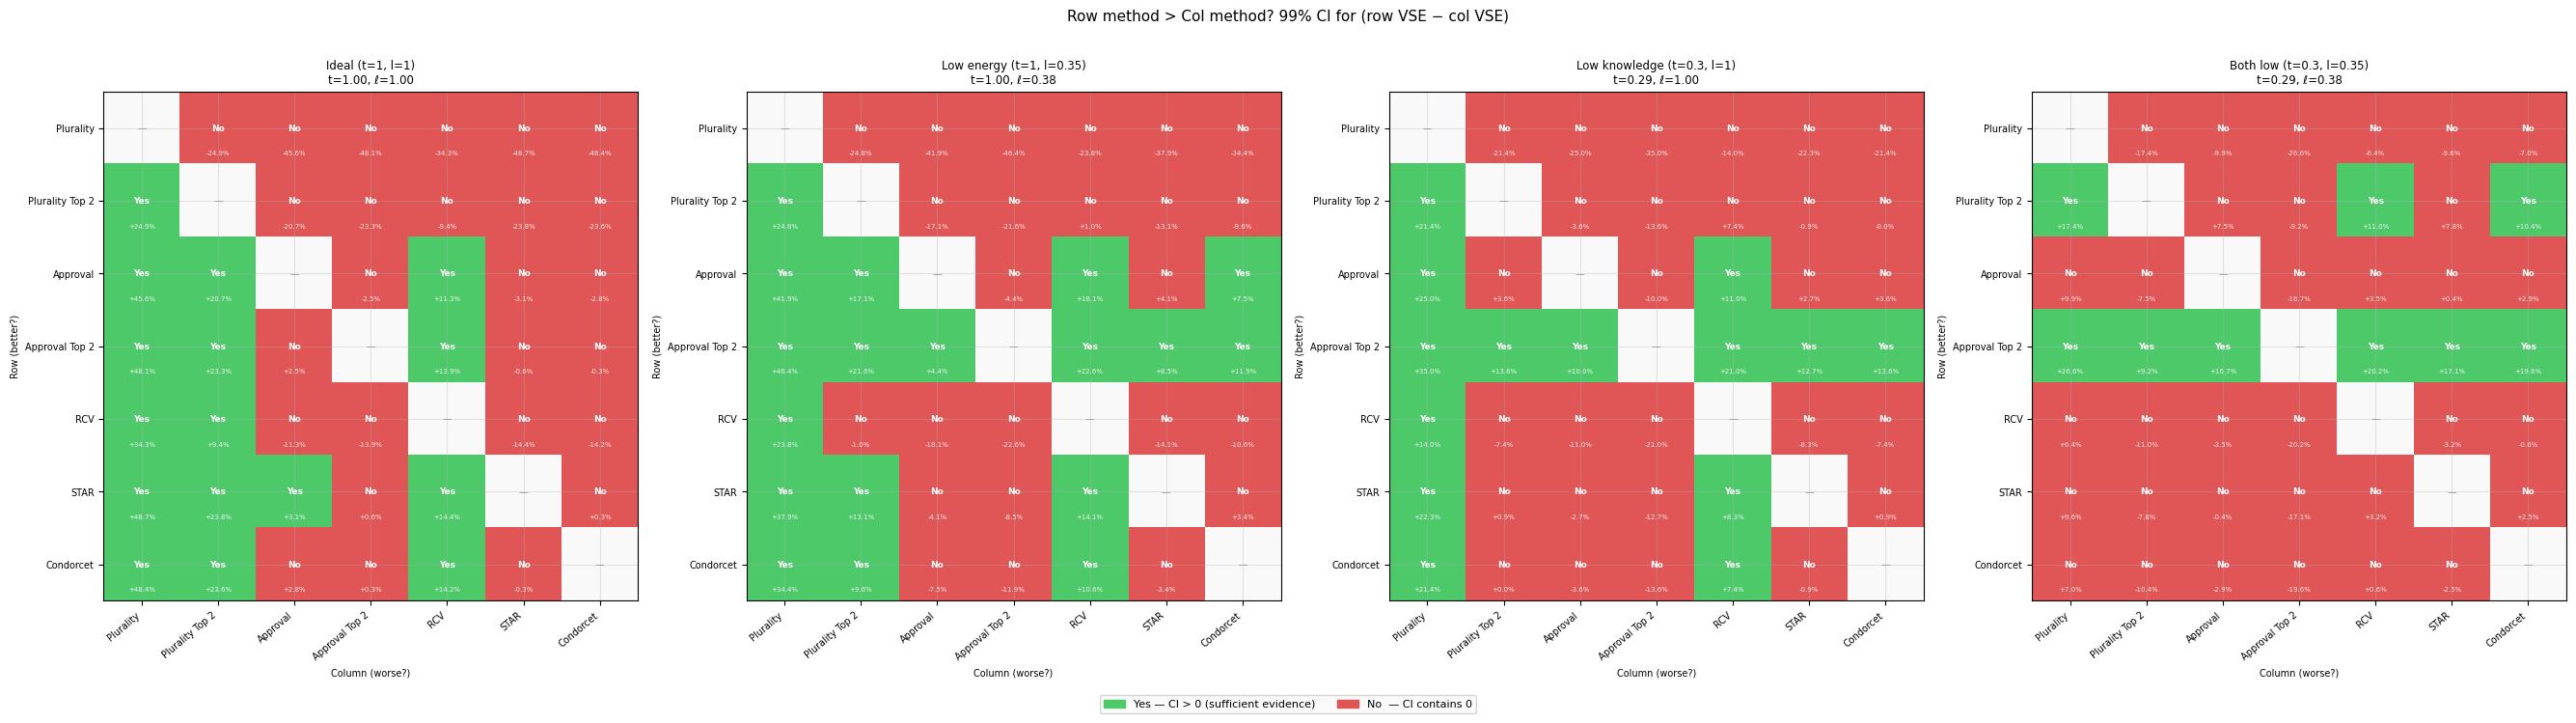

In [9]:
trial_vse = results['trial_vse']


def scenario_ci_matrix(li, ti, method_names, trial_vse):
    """Returns (n_m x n_m) matrix: 1=CI>0, 0=CI contains 0, nan=diagonal."""
    z99 = float(scipy_norm.ppf(0.995))
    n_m = len(method_names)
    mat = np.full((n_m, n_m), np.nan)
    ci_low = np.full((n_m, n_m), np.nan)
    ci_high = np.full((n_m, n_m), np.nan)
    means = np.full((n_m, n_m), np.nan)

    for ri, rm in enumerate(method_names):
        for ci, cm in enumerate(method_names):
            if ri == ci:
                continue
            a = trial_vse[rm][li, ti, :]
            b = trial_vse[cm][li, ti, :]
            d = a - b
            mn = np.mean(d)
            se = np.std(d, ddof=1) / np.sqrt(len(d))
            lo = mn - z99 * se
            hi = mn + z99 * se
            mat[ri, ci]    = 1.0 if lo > 0 else 0.0
            ci_low[ri, ci]  = lo
            ci_high[ri, ci] = hi
            means[ri, ci]   = mn

    return mat, ci_low, ci_high, means


def plot_scenario_matrices(scenario_specs, method_names, trial_vse):
    n_sc = len(scenario_specs)
    n_m  = len(method_names)
    cell_size = max(0.7, 5.5 / n_m)
    fig_w = n_sc * (n_m * cell_size + 1.2)
    fig_h = n_m * cell_size + 1.5

    fig, axes = plt.subplots(1, n_sc, figsize=(fig_w, fig_h))
    if n_sc == 1:
        axes = [axes]

    yes_color = '#4ec96a'
    no_color  = '#e05555'
    cmap = mcolors.ListedColormap([no_color, yes_color])

    for ax, sc in zip(axes, scenario_specs):
        li, ti = sc['li'], sc['ti']
        mat, ci_low, ci_high, means = scenario_ci_matrix(li, ti, method_names, trial_vse)

        ax.imshow(mat, cmap=cmap, vmin=0, vmax=1, aspect='auto')
        ax.set_xticks(range(n_m))
        ax.set_yticks(range(n_m))
        ax.set_xticklabels(method_names, rotation=40, ha='right', fontsize=7)
        ax.set_yticklabels(method_names, fontsize=7)
        ax.set_title(sc['label'] + f'\nt={sc["actual_t"]:.2f}, \u2113={sc["actual_l"]:.2f}',
                     fontsize=8.5)
        ax.set_xlabel('Column (worse?)', fontsize=7)
        ax.set_ylabel('Row (better?)', fontsize=7)

        for ri in range(n_m):
            for ci in range(n_m):
                if ri == ci:
                    ax.text(ci, ri, '—', ha='center', va='center', fontsize=7, color='#999')
                else:
                    txt = 'Yes' if mat[ri, ci] > 0.5 else 'No'
                    lo, hi = ci_low[ri, ci], ci_high[ri, ci]
                    detail = f'{means[ri,ci]:+.1%}'
                    color = 'white'
                    ax.text(ci, ri, txt, ha='center', va='center',
                            fontsize=6.5, color=color, fontweight='bold')
                    ax.text(ci, ri + 0.35, detail, ha='center', va='center',
                            fontsize=5, color='white', alpha=0.85)

    yes_patch = mpatches.Patch(color=yes_color, label='Yes — CI > 0 (sufficient evidence)')
    no_patch  = mpatches.Patch(color=no_color,  label='No  — CI contains 0')
    fig.legend(handles=[yes_patch, no_patch], loc='lower center',
               ncol=2, fontsize=8, bbox_to_anchor=(0.5, -0.04))
    plt.suptitle('Row method > Col method? 99% CI for (row VSE \u2212 col VSE)',
                 fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()


plot_scenario_matrices(scenario_specs, method_names, trial_vse)

## Scenario Hypothesis Tests — Detail Table
Prints the 99% CI and one-sided p-value for every method pair at each scenario.

In [10]:
def scenario_detail_table(scenario_specs, method_names, trial_vse, alpha=ALPHA):
    z99 = float(scipy_norm.ppf(0.995))
    rows = []
    for sc in scenario_specs:
        li, ti = sc['li'], sc['ti']
        for rm in method_names:
            for cm in method_names:
                if rm == cm:
                    continue
                d = trial_vse[rm][li, ti, :] - trial_vse[cm][li, ti, :]
                ms = one_sided_mean_test(d)
                lo = ms.get('lower_ci', np.nan)
                hi = ms.get('upper_ci', np.nan)
                excludes_zero = (lo > 0) if np.isfinite(lo) else False
                rows.append({
                    'Scenario':   sc['label'],
                    'Hypothesis': f'{rm} > {cm}',
                    'Mean diff':  ms['mean'],
                    'p (one-sided)': ms['p'],
                    '99% CI low':  lo,
                    '99% CI high': hi,
                    'CI > 0?':    'Yes' if excludes_zero else 'No',
                })
    return rows


detail_rows = scenario_detail_table(scenario_specs, method_names, trial_vse)

if HAS_PANDAS:
    import pandas as pd
    df_detail = pd.DataFrame(detail_rows)
    df_detail['Mean diff'] = df_detail['Mean diff'].map(lambda x: f'{x:+.2%}' if np.isfinite(x) else 'N/A')
    df_detail['p (one-sided)'] = df_detail['p (one-sided)'].map(lambda x: f'{x:.4f}' if np.isfinite(x) else 'N/A')
    df_detail['99% CI low']  = df_detail['99% CI low'].map(lambda x: f'{x:+.2%}' if np.isfinite(x) else 'N/A')
    df_detail['99% CI high'] = df_detail['99% CI high'].map(lambda x: f'{x:+.2%}' if np.isfinite(x) else 'N/A')

    def highlight_row(row):
        if row['CI > 0?'] == 'Yes':
            return ['background-color: #d4edda'] * len(row)
        return [''] * len(row)

    try:
        display(df_detail.style.apply(highlight_row, axis=1))
    except Exception:
        print(df_detail.to_string(index=False))
else:
    header = f"{'Scenario':<30} {'Hypothesis':<35} {'Mean diff':>10} {'p':>8} {'99% CI':>22} {'CI>0?':>6}"
    print(header)
    print('-' * len(header))
    for r in detail_rows:
        lo = f"{r['99% CI low']:+.2%}" if np.isfinite(r['99% CI low']) else 'N/A'
        hi = f"{r['99% CI high']:+.2%}" if np.isfinite(r['99% CI high']) else 'N/A'
        ci = f'[{lo}, {hi}]'
        md = f"{r['Mean diff']:+.2%}" if np.isfinite(r['Mean diff']) else 'N/A'
        p  = f"{r['p (one-sided)']:.4f}" if np.isfinite(r['p (one-sided)']) else 'N/A'
        print(f"{r['Scenario']:<30} {r['Hypothesis']:<35} {md:>10} {p:>8} {ci:>22} {r['CI > 0?']:>6}")

Scenario                       Hypothesis                           Mean diff        p                 99% CI  CI>0?
--------------------------------------------------------------------------------------------------------------------
Ideal (t=1, l=1)               Plurality > Plurality Top 2            -24.85%   1.0000     [-33.35%, -16.35%]     No
Ideal (t=1, l=1)               Plurality > Approval                   -45.59%   1.0000     [-56.68%, -34.50%]     No
Ideal (t=1, l=1)               Plurality > Approval Top 2             -48.11%   1.0000     [-58.76%, -37.47%]     No
Ideal (t=1, l=1)               Plurality > RCV                        -34.25%   1.0000     [-44.09%, -24.41%]     No
Ideal (t=1, l=1)               Plurality > STAR                       -48.67%   1.0000     [-59.21%, -38.14%]     No
Ideal (t=1, l=1)               Plurality > Condorcet                  -48.41%   1.0000     [-58.88%, -37.94%]     No
Ideal (t=1, l=1)               Plurality Top 2 > Plurality      

## Pooled Hypothesis Tests (Full Grid)

Pools all per-trial VSE differences across the entire $(t, \ell)$ grid for each method pair. Also reports Bonferroni-adjusted per-cell significance counts.

**How to read:**
- *Pooled Δ*: mean VSE difference across all grid cells and trials.
- *Pooled p (mean)*: one-sided test on all pooled differences.
- *Pooled p (sign)*: exact sign test on pooled differences.
- *Nominal sig cells*: cells where per-cell mean-diff p < α before correction.
- *Bonf sig cells*: cells surviving Bonferroni correction for all pair-cell combinations.

In [11]:
def compute_pooled_hypothesis_table(method_names, trial_vse, t_vals, l_vals, alpha=ALPHA):
    ng = len(t_vals)
    pairs = [(x, y) for x in method_names for y in method_names if x != y]

    all_mean_p = []
    all_sign_p = []
    refs = []
    per_pair = {}

    for x, y in pairs:
        key = f'{x} > {y}'
        pooled = []
        mean_p_grid = np.zeros((ng, ng))
        sign_p_grid = np.zeros((ng, ng))
        mean_d_grid = np.zeros((ng, ng))

        for li in range(ng):
            for ti in range(ng):
                d = trial_vse[x][li, ti, :] - trial_vse[y][li, ti, :]
                pooled.extend(d.tolist())
                ms = one_sided_mean_test(d)
                ss = one_sided_sign_test(d)
                mean_p_grid[li, ti] = ms['p']
                sign_p_grid[li, ti] = ss['p']
                mean_d_grid[li, ti] = ms['mean']
                all_mean_p.append(ms['p'])
                all_sign_p.append(ss['p'])
                refs.append({'pair': key, 'li': li, 'ti': ti})

        per_pair[key] = {
            'x': x, 'y': y,
            'mean_p_grid': mean_p_grid,
            'sign_p_grid': sign_p_grid,
            'mean_d_grid': mean_d_grid,
            'pooled_mean': one_sided_mean_test(pooled),
            'pooled_sign': one_sided_sign_test(pooled),
            'mean_p_adj_grid': np.zeros((ng, ng)),
            'sign_p_adj_grid': np.zeros((ng, ng)),
        }

    mean_adj = bonferroni_adjust(all_mean_p)
    sign_adj = bonferroni_adjust(all_sign_p)
    for i, ref in enumerate(refs):
        info = per_pair[ref['pair']]
        info['mean_p_adj_grid'][ref['li'], ref['ti']] = mean_adj[i]
        info['sign_p_adj_grid'][ref['li'], ref['ti']] = sign_adj[i]

    rows = []
    for x, y in pairs:
        key = f'{x} > {y}'
        info = per_pair[key]
        sig_nom = int(np.sum(info['mean_p_grid']    < alpha))
        sig_adj = int(np.sum(info['mean_p_adj_grid'] < alpha))
        sig_sgn = int(np.sum(info['sign_p_adj_grid'] < alpha))
        pm = info['pooled_mean']
        ps = info['pooled_sign']
        rows.append({
            'Hypothesis':           key,
            'Pooled delta':         pm['mean'],
            'Pooled p (mean-diff)': pm['p'],
            'Pooled p (sign)':      ps['p'],
            'Nominal sig cells':    sig_nom,
            'Bonf sig cells (mean)': sig_adj,
            'Bonf sig cells (sign)': sig_sgn,
            'Total cells':           ng * ng,
            # private fields for matrix colouring
            '_delta':    pm['mean'],
            '_mean_sig': pm['p'] < alpha,
            '_sign_sig': ps['p'] < alpha,
            '_adj_sig':  sig_adj > 0,
        })

    return rows, per_pair


hyp_rows, per_pair_data = compute_pooled_hypothesis_table(
    method_names, trial_vse, t_vals, l_vals
)

# ── Display table ─────────────────────────────────────────────────────────────
def fmt_p(p):
    if not np.isfinite(p): return 'N/A'
    if p < 1e-4: return f'{p:.2e}'
    return f'{p:.4f}'

display_rows = []
for r in sorted(hyp_rows, key=lambda x: x['Pooled p (mean-diff)']):
    nc_str = f"{r['Nominal sig cells']}/{r['Total cells']}"
    ba_str = f"{r['Bonf sig cells (mean)']}/{r['Total cells']}"
    bs_str = f"{r['Bonf sig cells (sign)']}/{r['Total cells']}"
    display_rows.append({
        'Hypothesis':              r['Hypothesis'],
        'Pooled \u0394':           f"{r['Pooled delta']:+.2%}" if np.isfinite(r['Pooled delta']) else 'N/A',
        'p (mean-diff)':           fmt_p(r['Pooled p (mean-diff)']),
        'p (sign)':                fmt_p(r['Pooled p (sign)']),
        'Nominal sig cells':       nc_str,
        'Bonf sig cells (mean)':   ba_str,
        'Bonf sig cells (sign)':   bs_str,
    })

print(f'Hypothesis Tests (alpha={ALPHA}, Bonferroni-corrected across {len(t_vals)**2 * len(hyp_rows)} tests)')
print()

if HAS_PANDAS:
    import pandas as pd
    df_hyp = pd.DataFrame(display_rows)

    def row_style(row):
        original = next((r for r in hyp_rows if r['Hypothesis'] == row['Hypothesis']), None)
        if original and original['_delta'] > 0 and original['_mean_sig'] and original['_sign_sig'] and original['_adj_sig']:
            return ['background-color: #d4edda'] * len(row)
        if original and (original['_delta'] < 0 or (not original['_mean_sig'] and not original['_sign_sig'])):
            return ['background-color: #f8d7da'] * len(row)
        return ['background-color: #fff3cd'] * len(row)

    try:
        display(df_hyp.style.apply(row_style, axis=1).set_caption(
            'Green = strong evidence for hypothesis; Yellow = mixed; Red = no evidence'
        ))
    except Exception:
        print(df_hyp.to_string(index=False))
else:
    cols = list(display_rows[0].keys())
    widths = [max(len(c), max(len(str(r[c])) for r in display_rows)) for c in cols]
    header = '  '.join(c.ljust(w) for c, w in zip(cols, widths))
    print(header)
    print('-' * len(header))
    for r in display_rows:
        print('  '.join(str(r[c]).ljust(w) for c, w in zip(cols, widths)))

Hypothesis Tests (alpha=0.01, Bonferroni-corrected across 2688 tests)

Hypothesis                        Pooled Δ  p (mean-diff)  p (sign)   Nominal sig cells  Bonf sig cells (mean)  Bonf sig cells (sign)
-------------------------------------------------------------------------------------------------------------------------------------
Plurality Top 2 > Plurality       +27.78%   0.00e+00       0.00e+00   64/64              64/64                  64/64                
Plurality Top 2 > Approval        +4.80%    0.00e+00       0.0044     24/64              18/64                  16/64                
Plurality Top 2 > RCV             +10.90%   0.00e+00       4.45e-79   33/64              22/64                  20/64                
Plurality Top 2 > STAR            +5.28%    0.00e+00       0.0105     28/64              18/64                  18/64                
Plurality Top 2 > Condorcet       +5.95%    0.00e+00       0.0009     28/64              20/64                  17/64        

## Pooled Pairwise Evidence Matrix
Summary matrix: green = pooled evidence supports row > col (all three criteria met); yellow = mixed; red = no evidence.

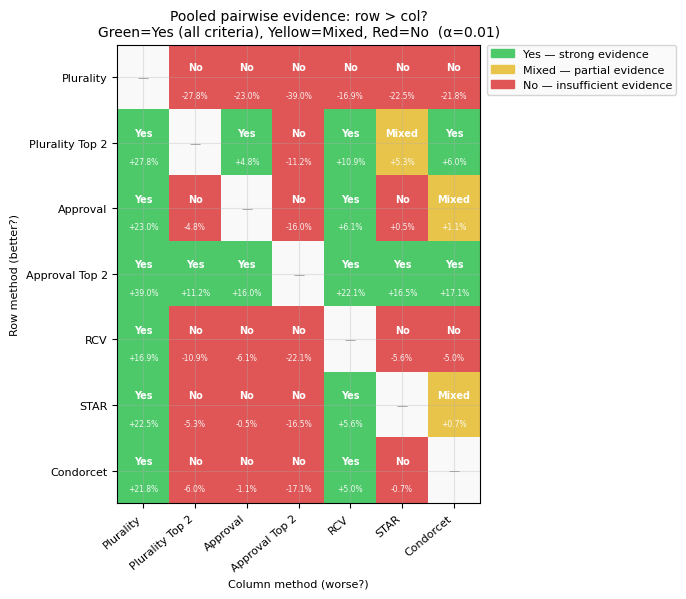

In [12]:
def plot_pooled_matrix(method_names, hyp_rows):
    n_m = len(method_names)
    m_to_i = {m: i for i, m in enumerate(method_names)}
    mat = np.full((n_m, n_m), np.nan)
    mean_mat = np.full((n_m, n_m), np.nan)

    for r in hyp_rows:
        x, y = r['Hypothesis'].split(' > ', 1)
        if x in m_to_i and y in m_to_i:
            ri, ci = m_to_i[x], m_to_i[y]
            mean_mat[ri, ci] = r['_delta']
            if r['_delta'] > 0 and r['_mean_sig'] and r['_sign_sig'] and r['_adj_sig']:
                mat[ri, ci] = 1.0   # strong evidence
            elif r['_delta'] > 0 and (r['_mean_sig'] or r['_sign_sig']):
                mat[ri, ci] = 0.5   # mixed
            else:
                mat[ri, ci] = 0.0   # no evidence

    cmap = mcolors.ListedColormap(['#e05555', '#e8c44a', '#4ec96a'])
    cell_size = max(0.8, 6.0 / n_m)
    fig, ax = plt.subplots(figsize=(n_m * cell_size + 1, n_m * cell_size * 0.85 + 1))
    ax.imshow(mat, cmap=cmap, vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(n_m))
    ax.set_yticks(range(n_m))
    ax.set_xticklabels(method_names, rotation=40, ha='right', fontsize=8)
    ax.set_yticklabels(method_names, fontsize=8)
    ax.set_title(
        f'Pooled pairwise evidence: row > col?\n'
        f'Green=Yes (all criteria), Yellow=Mixed, Red=No  (\u03b1={ALPHA})',
        fontsize=10
    )
    ax.set_xlabel('Column method (worse?)', fontsize=8)
    ax.set_ylabel('Row method (better?)', fontsize=8)

    for ri in range(n_m):
        for ci in range(n_m):
            if ri == ci:
                ax.text(ci, ri, '\u2014', ha='center', va='center', fontsize=8, color='#999')
            else:
                v = mat[ri, ci]
                txt = 'Yes' if v > 0.9 else ('Mixed' if v > 0.3 else 'No')
                delta_txt = f'{mean_mat[ri, ci]:+.1%}' if np.isfinite(mean_mat[ri, ci]) else ''
                ax.text(ci, ri - 0.15, txt, ha='center', va='center',
                        fontsize=7, color='white', fontweight='bold')
                ax.text(ci, ri + 0.28, delta_txt, ha='center', va='center',
                        fontsize=5.5, color='white', alpha=0.9)

    yes_p   = mpatches.Patch(color='#4ec96a', label='Yes — strong evidence')
    mix_p   = mpatches.Patch(color='#e8c44a', label='Mixed — partial evidence')
    no_p    = mpatches.Patch(color='#e05555', label='No — insufficient evidence')
    ax.legend(handles=[yes_p, mix_p, no_p], loc='upper left',
              bbox_to_anchor=(1.02, 1), fontsize=8, borderaxespad=0)
    plt.tight_layout()
    plt.show()


plot_pooled_matrix(method_names, hyp_rows)